# Exploratory Data Analysis & Data Cleaning
## AIoT-Sol Dataset (6G) — Cyber-Attack Prediction in 6G IoT Smart City Networks

---

### Project Overview

This notebook implements a complete data science pipeline for the **AIoT-Sol Dataset (6G)**, a network traffic dataset captured in a simulated 6G-enabled IoT Smart City environment. The overarching objective is to build a robust anomaly detection system capable of identifying cyber-attacks (e.g., DDoS, port scans, SYN floods) within high-throughput, heterogeneous IoT traffic flows.

The pipeline is structured in two major phases:

1. **Phase 1 — Exploratory Data Analysis (EDA) & Data Cleaning:** Systematic characterisation of the raw dataset, followed by a semantics-aware preprocessing pipeline designed to preserve the informational structure of network traffic features.
2. **Phase 2 — Modelling & Evaluation:** Unsupervised anomaly detection using an Autoencoder (deep learning) and Isolation Forest (ensemble machine learning), followed by a rigorous comparative evaluation.

### Dataset Context

The AIoT-Sol 6G dataset consists of **network flow records** generated by CICFlowMeter, each row representing a bidirectional flow with ~80 statistical features (packet counts, byte rates, inter-arrival times, TCP flags, etc.). The `Label` column designates each flow as either *Benign* or a specific attack type.

**Key methodological considerations:**
- Network traffic features exhibit severe right-skew and multi-modal distributions due to the heterogeneity of IoT device behaviours.
- Many features are redundant or derive from the same underlying measurement (e.g., forward/backward packet length statistics).
- Flag-based features (SYN, RST, ACK counts) require domain-aware treatment: their extreme values are attack signatures, not noise.


---
## 1. Library Imports & Configuration

### Objective
Load all required libraries and configure global display and visualisation settings. Reproducibility is ensured by fixing random seeds and suppressing non-critical warnings.

### Libraries Used

| Library | Role |
|---|---|
| `pandas`, `numpy` | Data manipulation and numerical computation |
| `matplotlib`, `seaborn` | Statistical visualisation |
| `scipy.stats` | Skewness, kurtosis, Box-Cox transformation, z-score outlier detection |
| `sklearn` | Preprocessing (StandardScaler), feature selection, ensemble models |
| `warnings` | Suppression of deprecation and convergence warnings |


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, zscore
from scipy.stats import boxcox
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('✓ All libraries loaded successfully')
print(f'  pandas  : {pd.__version__}')
print(f'  numpy   : {np.__version__}')
print(f'  seaborn : {sns.__version__}')


✓ All libraries loaded successfully
  pandas  : 2.2.2
  numpy   : 2.0.2
  seaborn : 0.13.2


**Configuration notes:**
- `pd.set_option('display.float_format', '{:.4f}'.format)` ensures consistent 4-decimal precision for numerical outputs.
- `seaborn-v0_8-darkgrid` style and the `husl` colour palette are selected for perceptual uniformity across all plots in this notebook.


---
## 2. Dataset Loading & High-Level Inspection

### Objective
Load the raw AIoT-Sol 6G CSV file into memory and perform an initial structural audit: shape, memory footprint, column types, and a preview of the first rows. An immutable copy (`df_raw`) is retained throughout the notebook to enable rollback if needed.

### Key Inspection Dimensions
- **Shape:** Number of flow records (rows) and features (columns).
- **Memory footprint:** Identifies whether memory optimisation (e.g., dtype downcasting) will be required.
- **Type distribution:** Ratio of numerical vs. object columns informs the encoding strategy.


In [43]:
print('='*70)
print('STEP 1 : DATASET LOADING')
print('='*70)

df_raw = pd.read_csv('AIoT-Sol Dataset(6G).csv')
df     = df_raw.copy()  # Working copy — df_raw never modified

print(f'\n  Shape        : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'  Memory       : {df.memory_usage(deep=True).sum()/1e6:.2f} MB')
print(f'  Types        : {dict(df.dtypes.value_counts())}')
print(f'  Numeric cols : {df.select_dtypes(include=np.number).shape[1]}')
print(f'  Object cols  : {df.select_dtypes(include="object").shape[1]}')
print()
print('  First rows:')
df.head(3)


STEP 1 : DATASET LOADING

  Shape        : 5,222 rows × 85 columns
  Memory       : 3.80 MB
  Types        : {dtype('float64'): np.int64(63), dtype('int64'): np.int64(21), dtype('O'): np.int64(1)}
  Numeric cols : 84
  Object cols  : 1

  First rows:


,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,External IP
0,14492,199,89,267,63475,6,42,726,1,2,0.0000,0.0000,0,0,0.0000,0.0000,0,0,0.0000,0.0000,0,4132,363.0000,166.8772,481.0000,245.0000,0.0000,0.0000,0.0000,0.0000,0.0000,245.0000,245.0000,0.0000,245.0000,245.0000,0,0,0,0,20,40.0000,1377.4105,2754.8209,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,0.0000,0.0000,0.0000,3.0000,0.0000,0.0000,0.0000,2.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,140.0000,511.0000,0.0000,20.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,Benign,0.0000
1,14457,199,89,267,61802,6,42,2704,1,2,0.0000,0.0000,0,0,0.0000,0.0000,0,0,0.0000,0.0000,0,1109,1352.0000,579.8276,1762.0000,942.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1762.0000,1762.0000,0.0000,1762.0000,1762.0000,0,0,0,0,20,40.0000,369.8225,739.6450,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,0.0000,0.0000,0.0000,3.0000,0.0000,0.0000,0.0000,2.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,139.0000,510.0000,0.0000,20.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,Benign,0.0000
2,377,101,53,261,60658,6,42,314,1,1,0.0000,0.0000,0,0,0.0000,0.0000,0,0,0.0000,0.0000,0,6369,314.0000,0.0000,314.0000,314.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,0,0,0,32,32.0000,3184.7134,3184.7134,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,0.0000,0.0000,0.0000,2.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,227.0000,502.0000,0.0000,32.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,Benign,0.0000


In [44]:
print('='*70)
print('COLUMNS & DATA TYPES')
print('='*70)
print(df.dtypes.to_string())


COLUMNS & DATA TYPES
Flow ID                          int64
Source IP                        int64
Source Port                      int64
Destination IP                   int64
Destination Port                 int64
Protocol                         int64
Timestamp                        int64
Flow Duration                    int64
Total Fwd Packets                int64
Total Backward Packets           int64
Total Length of Fwd Packets    float64
Total Length of Bwd Packets    float64
Fwd Packet Length Max            int64
Fwd Packet Length Min            int64
Fwd Packet Length Mean         float64
Fwd Packet Length Std          float64
Bwd Packet Length Max            int64
Bwd Packet Length Min            int64
Bwd Packet Length Mean         float64
Bwd Packet Length Std          float64
Flow Bytes/s                     int64
Flow Packets/s                   int64
Flow IAT Mean                  float64
Flow IAT Std                   float64
Flow IAT Max                   float64
Flow

In [45]:
print('='*70)
print('DESCRIPTIVE STATISTICS — NUMERICAL COLUMNS')
print('='*70)
df.describe().T


DESCRIPTIVE STATISTICS — NUMERICAL COLUMNS


,count,mean,std,min,25%,50%,75%,max
Flow ID,5222.0000,7281.0193,4152.4005,1.0000,3654.7500,7417.5000,10611.0000,14523.0000
Source IP,5222.0000,111.3962,17.1069,1.0000,107.0000,111.0000,116.0000,199.0000
Source Port,5222.0000,46856.6342,20701.6974,0.0000,49220.7500,54029.0000,59910.2500,65526.0000
Destination IP,5222.0000,298.9435,128.9775,1.0000,254.0000,256.0000,369.0000,627.0000
Destination Port,5222.0000,7143.1624,17916.9742,0.0000,53.0000,443.0000,443.0000,65359.0000
...,...,...,...,...,...,...,...,...
Idle Mean,5221.0000,7490480.4276,17177816.0411,0.0000,0.0000,0.0000,0.0000,119000000.0000
Idle Std,5221.0000,1075521.1345,4705506.2465,0.0000,0.0000,0.0000,0.0000,53400000.0000
Idle Max,5221.0000,8414724.4154,18639549.9317,0.0000,0.0000,0.0000,0.0000,119000000.0000
Idle Min,5221.0000,6684482.0707,16558492.2321,0.0000,0.0000,0.0000,0.0000,119000000.0000


**Interpretation of Descriptive Statistics:**
- The `count` row confirms whether each column contains missing values (a count below the total row count signals NaN presence).
- Wide gaps between `mean` and `50%` (median) for flow metrics (e.g., `Flow Bytes/s`, `Flow Duration`) indicate strong **right-skew**, consistent with network traffic where a small number of flows dominate throughput.
- Extremely large `max` values relative to `75%` percentiles suggest **heavy-tailed distributions** and the presence of statistical outliers — a recurring characteristic of network traffic datasets.
- Features with `std = 0` are constant and carry no predictive information; they will be identified and removed in the cleaning phase.


---
## 3. Missing Values Analysis

### Objective
Quantify and locate missing values across all columns, with particular attention to the target variable `Label`. Missing values in the response variable render rows unusable for supervised evaluation and must be removed prior to any analysis.

### Methodology
- **Global audit:** Compute the count and percentage of NaN values per column.
- **Label audit:** Specifically identify rows where `Label` is NaN, as these cannot be used for model validation.

### Expected Findings
In network flow datasets generated by CICFlowMeter, missing values typically arise in **rate-derived features** (e.g., `Flow Bytes/s = Total Bytes / Flow Duration`) when `Flow Duration ≈ 0`, producing `Inf` or `NaN`. This missingness pattern is **informative** (indicative of degenerate flows such as SYN floods or port scans) and will be handled with dedicated indicator variables in the cleaning phase.


In [46]:
print('='*70)
print('STEP 2 : MISSING VALUES ANALYSIS')
print('='*70)

missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count' : missing_count,
    'Missing %'     : missing_pct
}).query('`Missing Count` > 0').sort_values('Missing Count', ascending=False)

total_missing = df.isnull().sum().sum()
total_cells   = df.shape[0] * df.shape[1]

print(f'\n  Total missing cells    : {total_missing}')
print(f'  Overall missing %      : {total_missing/total_cells*100:.4f}%')
print(f'  Affected columns       : {len(missing_df)}/{df.shape[1]}')

if len(missing_df) > 0:
    print(f'\n  Detail:')
    print(missing_df.to_string())

# Inspect rows with NaN in Label
print('\n' + '-'*70)
print('  ⚠️  ROWS WITH NaN IN LABEL:')
label_nan_rows = df[df['Label'].isna()]
print(f'  Count: {len(label_nan_rows)}')
if len(label_nan_rows) > 0:
    print(label_nan_rows[['Label','Flow Duration','Total Fwd Packets',
                           'Total Backward Packets','Protocol']].to_string())


STEP 2 : MISSING VALUES ANALYSIS

  Total missing cells    : 44
  Overall missing %      : 0.0099%
  Affected columns       : 44/85

  Detail:
                         Missing Count  Missing %
Bwd Header Length                    1     0.0191
Fwd Packets/s                        1     0.0191
Bwd Packets/s                        1     0.0191
Min Packet Length                    1     0.0191
Max Packet Length                    1     0.0191
Packet Length Mean                   1     0.0191
Packet Length Std                    1     0.0191
Packet Length Variance               1     0.0191
FIN Flag Count                       1     0.0191
SYN Flag Count                       1     0.0191
RST Flag Count                       1     0.0191
PSH Flag Count                       1     0.0191
ACK Flag Count                       1     0.0191
URG Flag Count                       1     0.0191
CWE Flag Count                       1     0.0191
ECE Flag Count                       1     0.0191
Down/Up

**Key Observations:**
- If `Flow Bytes/s` or `Flow Packets/s` exhibit the highest missing rates, this confirms the rate-derivation hypothesis: flows with near-zero duration produce undefined rates.
- Rows with `NaN` in `Label` are entirely uninformative for anomaly detection evaluation and will be dropped in Cleaning Step N1.
- A low global missing percentage (< 1%) confirms that imputation — rather than column deletion — is the appropriate remediation strategy.


---
## 4. Target Variable (Label) Analysis

### Objective
Characterise the class distribution of the target variable `Label` to inform modelling strategy. Understanding the prevalence of each class is critical for selecting appropriate algorithms and evaluation metrics.

### Significance for Modelling
- **Severe class imbalance** (common in intrusion detection datasets) invalidates accuracy as a primary metric and motivates the use of F1-score, AUC-ROC, and PR-AUC.
- A dataset containing **exclusively benign traffic** necessitates an unsupervised or one-class anomaly detection approach, as no labelled attack examples are available for supervised training.


STEP 3 : TARGET VARIABLE (LABEL) ANALYSIS

  Label distribution:
    Benign          :   5221 (99.98%)
    nan             :      1 (0.02%)

  ⚠️  NOTE: This dataset contains only Benign traffic.
       It will be used for anomaly detection modelling
       (One-Class / Autoencoder) in the modelling phase.


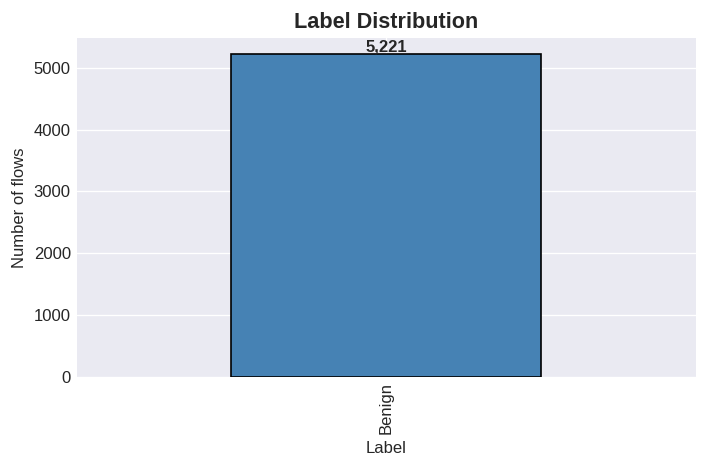

In [47]:
print('='*70)
print('STEP 3 : TARGET VARIABLE (LABEL) ANALYSIS')
print('='*70)

label_counts = df['Label'].value_counts(dropna=False)
label_pct    = df['Label'].value_counts(normalize=True, dropna=False) * 100

print(f'\n  Label distribution:')
for label in label_counts.index:
    print(f'    {str(label):<15} : {label_counts[label]:>6} ({label_pct[label]:.2f}%)')

print(f'\n  ⚠️  NOTE: This dataset contains only Benign traffic.')
print(f'       It will be used for anomaly detection modelling')
print(f'       (One-Class / Autoencoder) in the modelling phase.')

fig, ax = plt.subplots(figsize=(6, 4))
label_counts.drop(index=np.nan, errors='ignore').plot(
    kind='bar', ax=ax, color=['steelblue'], edgecolor='black'
)
ax.set_title('Label Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Label')
ax.set_ylabel('Number of flows')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()


**Interpretation:**
- If the dataset contains only `Benign` flows, a **one-class classification** strategy (Autoencoder, Isolation Forest) is the methodologically correct choice: the model learns the statistical profile of normal traffic and flags deviations as anomalies.
- This design is operationally realistic: in production IDS/IPS systems, labelled attack traffic is rarely available in sufficient volume; models must generalise from normal behaviour.
- The bar chart provides a visual confirmation of class distribution; annotated counts enable quick identification of any extreme imbalance.


---
## 5. Univariate Analysis

### Objective
Characterise the marginal distribution of each numerical feature through:
1. **Constant/quasi-constant column detection** — features with zero or near-zero variance that contribute no discriminative information.
2. **Skewness and kurtosis analysis** — quantification of distributional asymmetry to identify features requiring transformation.
3. **Histogram + KDE visualisation** — visual confirmation of distribution shape for key network traffic features.
4. **Boxplot analysis** — visual outlier detection highlighting IQR-based extreme values.

### Theoretical Background
Network flow features (byte rates, packet counts, inter-arrival times) are inherently **multiplicative-scale** measurements: they span multiple orders of magnitude and follow approximately log-normal distributions. Skewness values |s| > 1 indicate that standard normality assumptions are violated, necessitating log transformation prior to scaling.


In [48]:
print('='*70)
print('STEP 4A : CONSTANT / QUASI-CONSTANT COLUMN DETECTION')
print('='*70)

num_cols = df.select_dtypes(include=np.number).columns.tolist()

# Columns with zero variance (constant)
zero_var_cols = [c for c in num_cols if df[c].std() == 0]
print(f'\n  Constant columns (std=0): {len(zero_var_cols)}')
for c in zero_var_cols:
    print(f'    ✗ {c:<40} unique value = {df[c].unique()[0]}')

# Quasi-constant columns (one value > 99% of rows)
quasi_const_cols = []
for c in num_cols:
    top_freq = df[c].value_counts(normalize=True).iloc[0]
    if top_freq > 0.99 and c not in zero_var_cols:
        quasi_const_cols.append((c, top_freq))

print(f'\n  Quasi-constant columns (>99% same value): {len(quasi_const_cols)}')
for c, freq in quasi_const_cols:
    dominant_val = df[c].value_counts().index[0]
    print(f'    ⚠ {c:<40} {freq*100:.1f}% = {dominant_val}')


STEP 4A : CONSTANT / QUASI-CONSTANT COLUMN DETECTION

  Constant columns (std=0): 10
    ✗ Bwd PSH Flags                            unique value = 0
    ✗ Fwd URG Flags                            unique value = 0
    ✗ Bwd URG Flags                            unique value = 0
    ✗ URG Flag Count                           unique value = 0.0
    ✗ CWE Flag Count                           unique value = 0.0
    ✗ ECE Flag Count                           unique value = 0.0
    ✗ Fwd Avg Bytes/Bulk                       unique value = 0.0
    ✗ Fwd Avg Packets/Bulk                     unique value = 0.0
    ✗ Fwd Avg Bulk Rate                        unique value = 0.0
    ✗ External IP                              unique value = 0.0

  Quasi-constant columns (>99% same value): 0


**Interpretation:**
- **Constant columns** (`std = 0`): These features take a single value across all observations and provide zero discriminative power. They will be unconditionally dropped in Cleaning Step N3.
- **Quasi-constant columns** (one value > 99% of rows): While not strictly constant, these features are near-degenerate and are unlikely to contribute to anomaly detection. They are flagged for review and removal.
- TCP flag columns (e.g., `URG Flag Count`, `CWE Flag Count`) are frequently quasi-constant in benign traffic datasets, as unusual flags (URG, CWE, ECE) are rarely set in normal IoT communication.


In [49]:
print('='*70)
print('STEP 4B : SKEWNESS ANALYSIS — ALL NUMERICAL FEATURES')
print('='*70)

skew_data = []
for col in num_cols:
    data = df[col].dropna()
    if data.std() > 0:
        s = skew(data)
        k = kurtosis(data)
        if abs(s) > 1:
            cat = 'Highly Skewed'
        elif abs(s) > 0.5:
            cat = 'Moderately Skewed'
        else:
            cat = 'Symmetric'
        skew_data.append({'Feature': col, 'Skewness': round(s,3),
                          'Kurtosis': round(k,3), 'Category': cat})

skew_df = pd.DataFrame(skew_data).sort_values('Skewness', ascending=False)

highly_skewed = skew_df[skew_df['Skewness'].abs() > 1]
print(f'\n  Highly skewed features (|skew|>1) : {len(highly_skewed)}/{len(skew_df)}')
print(f'  Symmetric features                : {len(skew_df[skew_df["Category"]=="Symmetric"])}/{len(skew_df)}')
print()
print(skew_df.to_string(index=False))


STEP 4B : SKEWNESS ANALYSIS — ALL NUMERICAL FEATURES

  Highly skewed features (|skew|>1) : 68/74
  Symmetric features                : 2/74

                    Feature  Skewness  Kurtosis          Category
              Bwd Packets/s   69.0650 4898.5000     Highly Skewed
             Flow Packets/s   67.9550 4792.1690     Highly Skewed
              Fwd Packets/s   64.6770 4472.9180     Highly Skewed
          Subflow Fwd Bytes   50.6730 2803.3450     Highly Skewed
             PSH Flag Count   40.6540 1993.4720     Highly Skewed
        Subflow Fwd Packets   38.6080 1793.6120     Highly Skewed
               Flow IAT Min   37.6220 1663.8900     Highly Skewed
          Subflow Bwd Bytes   31.4970 1306.3160     Highly Skewed
        Subflow Bwd Packets   27.8750 1037.8680     Highly Skewed
         Bwd Avg Bytes/Bulk   23.8770  626.8760     Highly Skewed
       Bwd Avg Packets/Bulk   23.4820  611.6050     Highly Skewed
Total Length of Fwd Packets   21.8050  570.2320     Highly Skewed


**Interpretation of Skewness Analysis:**
- Features with |skewness| > 1 are classified as **highly skewed** and are primary candidates for log transformation in Cleaning Step N9.
- The high proportion of highly skewed features is expected in network traffic data: most flows transmit small volumes (low byte counts, short durations), while a minority of flows (e.g., bulk file transfers, streaming) produce extreme values, creating long right tails.
- **Kurtosis** complements skewness: high excess kurtosis (leptokurtic distributions) indicates heavy tails and a higher probability of extreme observations — reinforcing the need for outlier treatment.
- Flag count features may exhibit artificially high skewness due to their discrete, sparse nature (most values are 0); this structural skewness should **not** be corrected by log transformation.


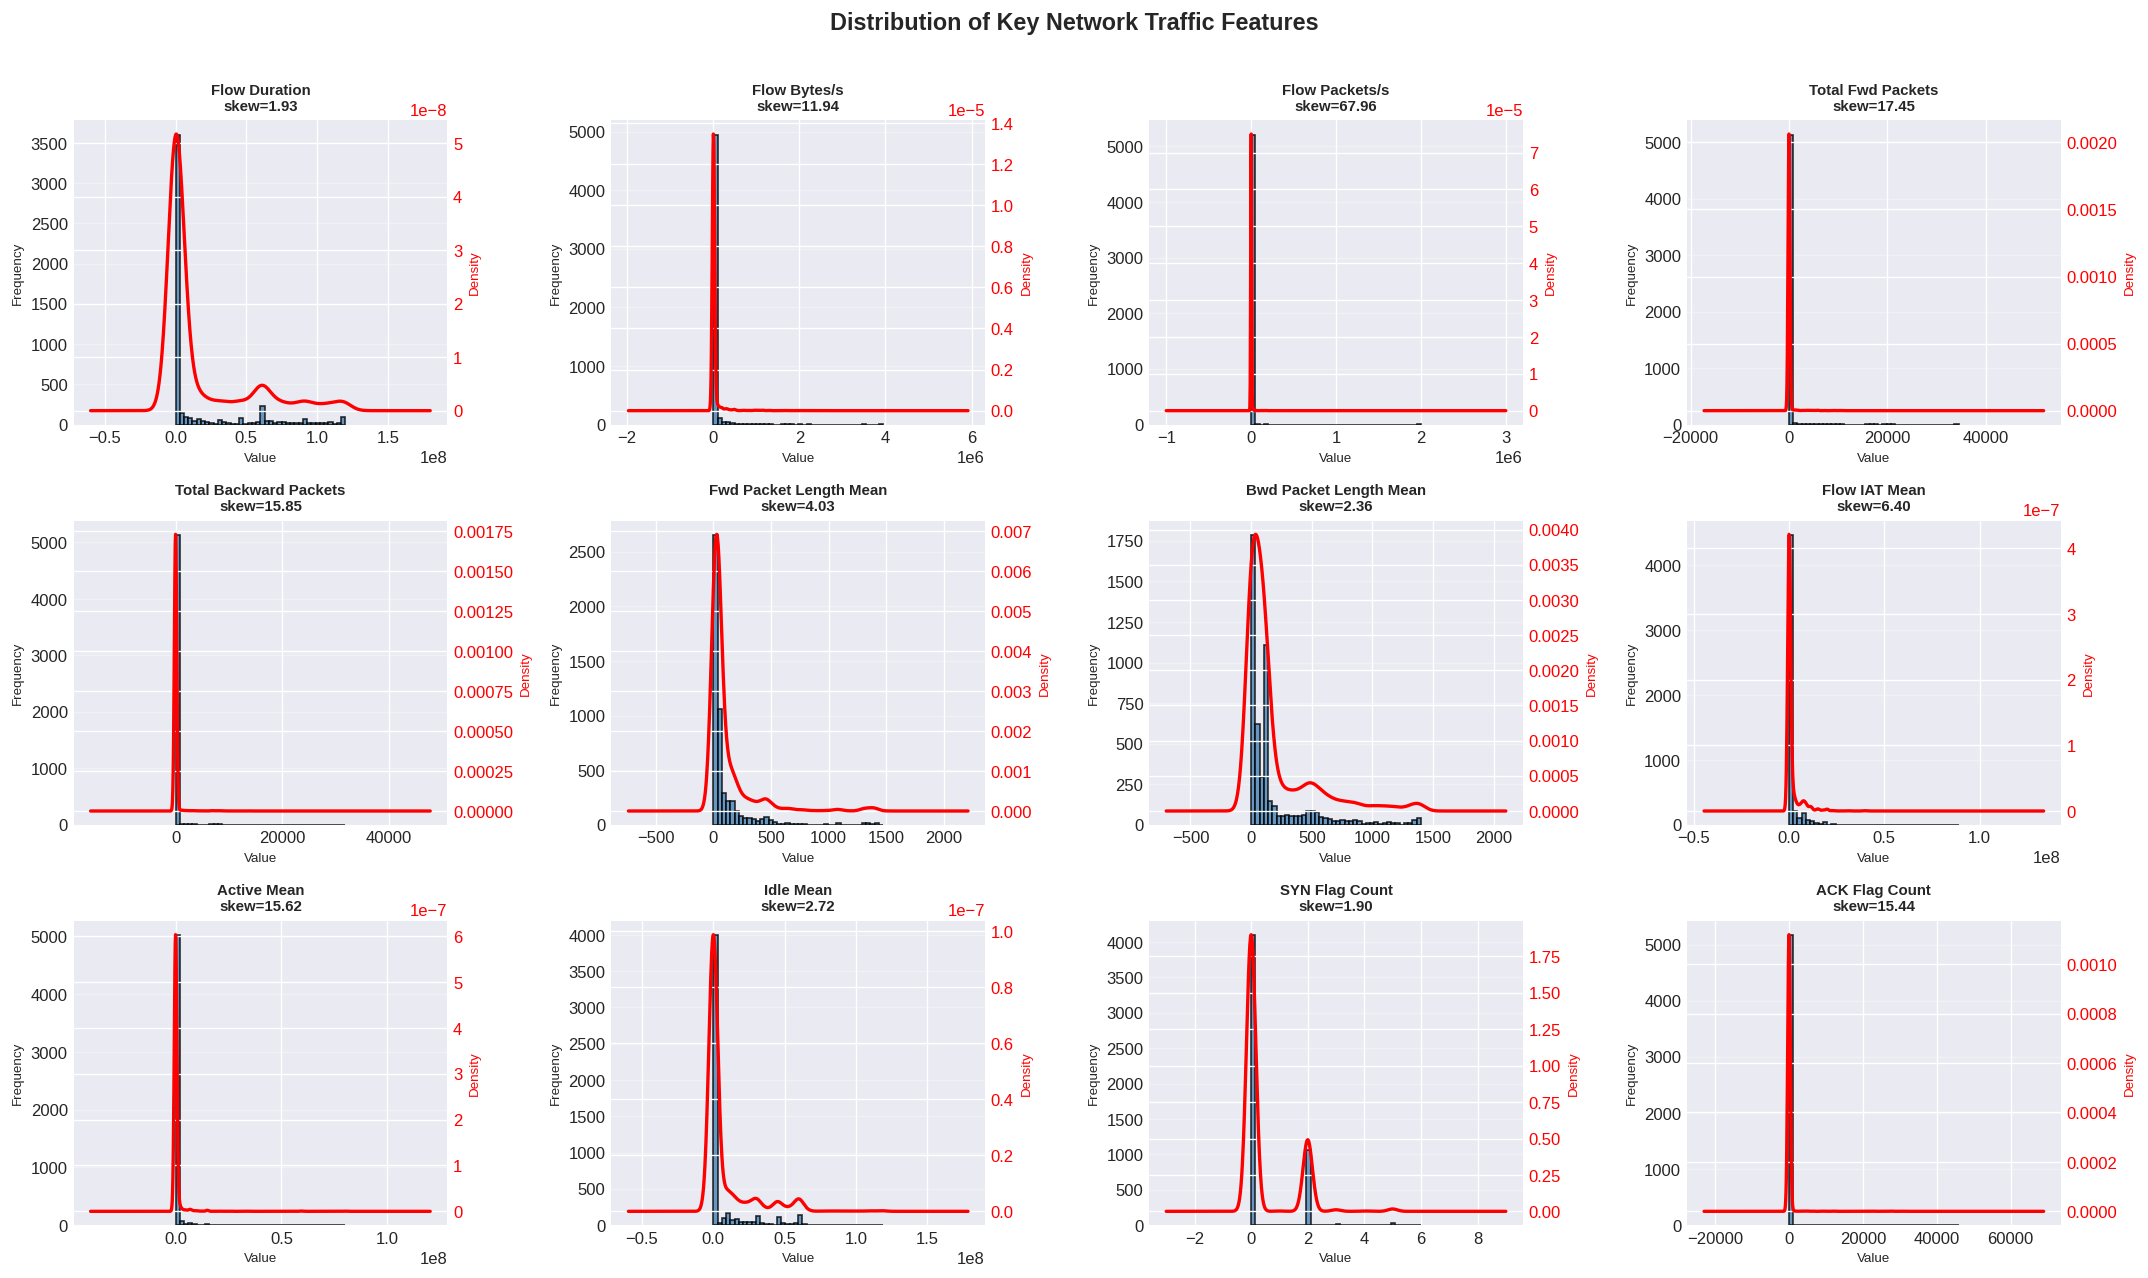

In [50]:
# Histograms of key network traffic features
key_features = [
    'Flow Duration', 'Flow Bytes/s', 'Flow Packets/s',
    'Total Fwd Packets', 'Total Backward Packets',
    'Fwd Packet Length Mean', 'Bwd Packet Length Mean',
    'Flow IAT Mean', 'Active Mean', 'Idle Mean',
    'SYN Flag Count', 'ACK Flag Count'
]
key_features = [f for f in key_features if f in df.columns]

n_cols = 4
n_rows = -(-len(key_features) // n_cols)  # ceil division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

for idx, col in enumerate(key_features):
    data = df[col].dropna()
    ax   = axes[idx]
    ax.hist(data, bins=40, color='steelblue', edgecolor='black', alpha=0.8)
    if data.std() > 0:
        ax2 = ax.twinx()
        data.plot(kind='density', ax=ax2, color='red', linewidth=2)
        ax2.set_ylabel('Density', color='red', fontsize=8)
        ax2.tick_params(axis='y', colors='red')
    s = skew(data)
    ax.set_title(f'{col}\nskew={s:.2f}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Value', fontsize=8)
    ax.set_ylabel('Frequency', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

# Hide empty axes
for idx in range(len(key_features), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Distribution of Key Network Traffic Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


**Interpretation of Distribution Plots:**
- The overlaid KDE (red curve) provides a smooth estimate of the probability density, highlighting multi-modality or heavy tails that raw histograms may obscure.
- Features such as `Flow Duration` and `Flow Bytes/s` are expected to display strongly right-skewed, unimodal distributions with a long upper tail.
- Features like `SYN Flag Count` and `ACK Flag Count` are expected to show spike-at-zero distributions, reflecting the dominance of flows with no flag activity.
- The skewness value annotated in each subplot title provides a quantitative summary aligned with the analysis in Step 4B.


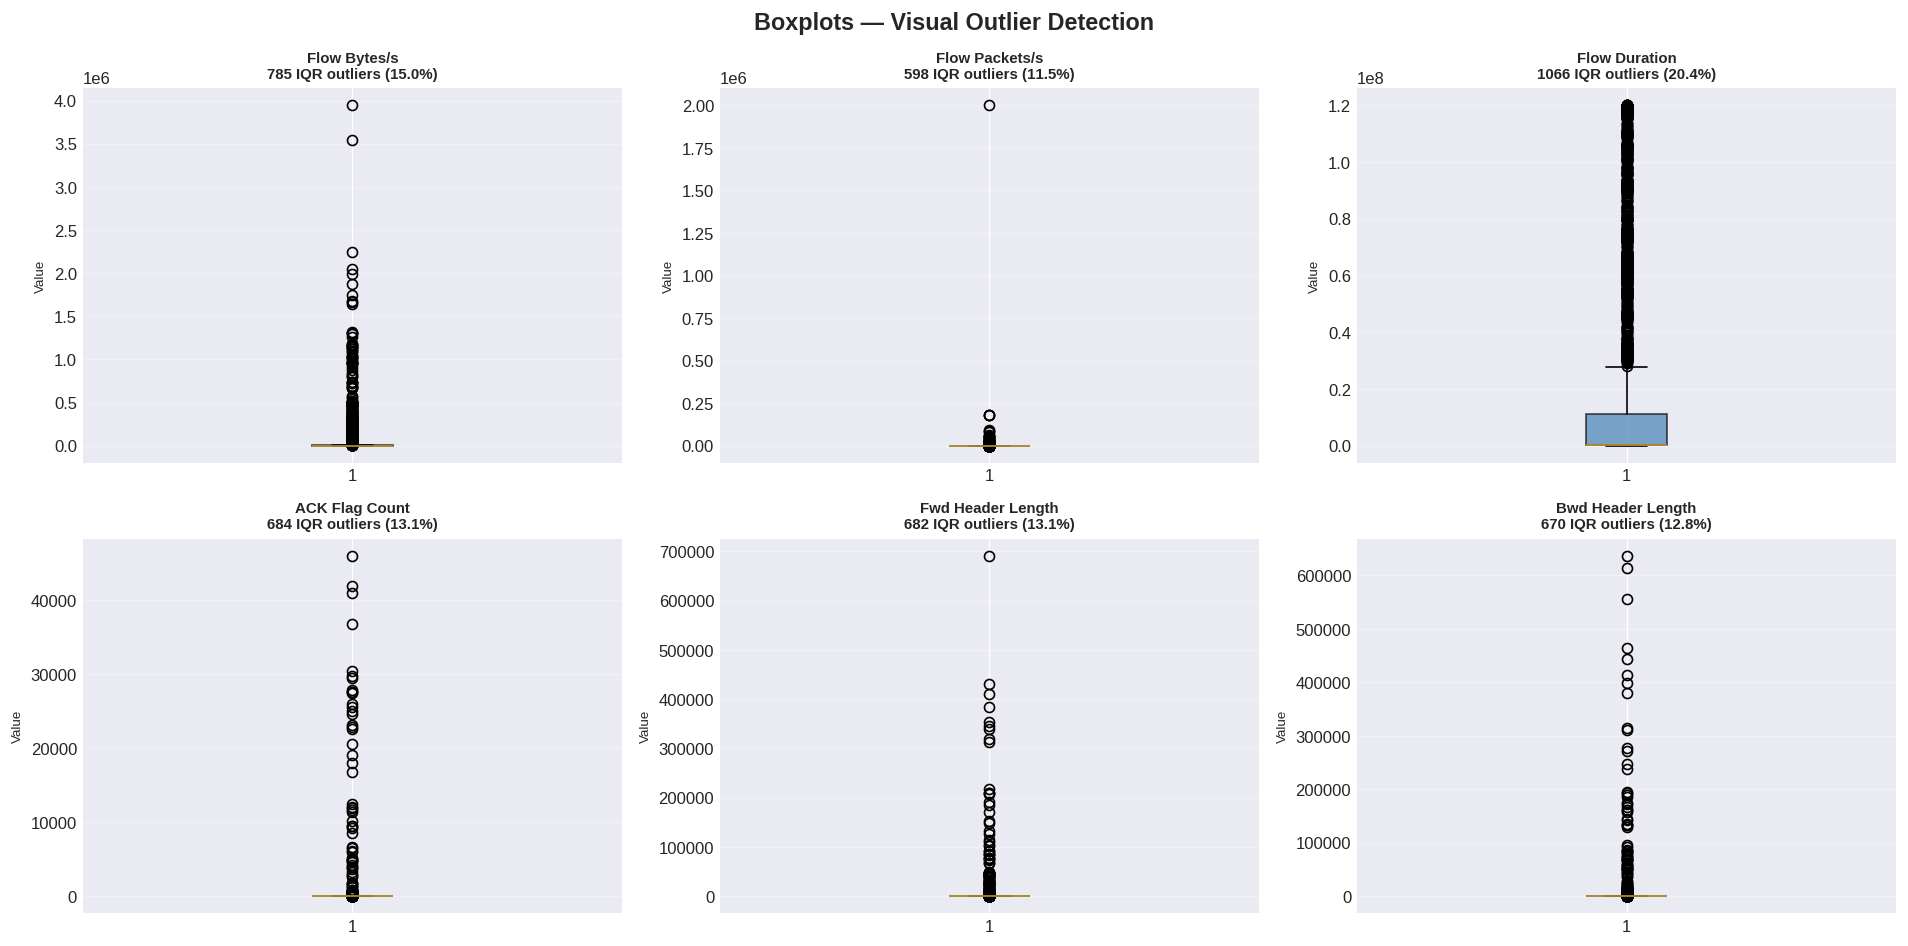

In [51]:
# Boxplots for visual outlier detection
outlier_features = [
    'Flow Bytes/s', 'Flow Packets/s', 'Flow Duration',
    'ACK Flag Count', 'Fwd Header Length', 'Bwd Header Length'
]
outlier_features = [f for f in outlier_features if f in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for idx, col in enumerate(outlier_features):
    data = df[col].dropna()
    axes[idx].boxplot(data, vert=True, patch_artist=True,
                      boxprops=dict(facecolor='steelblue', alpha=0.7))
    q1, q3 = data.quantile([0.25, 0.75])
    iqr     = q3 - q1
    n_out   = ((data < q1-1.5*iqr) | (data > q3+1.5*iqr)).sum()
    axes[idx].set_title(f'{col}\n{n_out} IQR outliers ({n_out/len(data)*100:.1f}%)',
                        fontsize=9, fontweight='bold')
    axes[idx].set_ylabel('Value', fontsize=8)
    axes[idx].grid(axis='y', alpha=0.3)

plt.suptitle('Boxplots — Visual Outlier Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Interpretation of Boxplots:**
- Each boxplot annotates the **IQR outlier count and percentage**, providing a quantitative outlier profile per feature.
- In network traffic datasets, IQR outliers are not necessarily measurement errors — they often represent legitimate but rare behaviours (e.g., large file transfers) or early-stage attacks. This distinction motivates **capping rather than deletion** in Cleaning Step N8.
- Features like `Flow Bytes/s` and `Flow Packets/s` are expected to show numerous outliers due to their rate-derived nature and high sensitivity to flow duration variability.

> **Methodological Note:** The choice of the IQR method (Tukey's fences) is appropriate here because it is non-parametric and does not assume Gaussian distributions — a key requirement given the observed skewness.


---
## 6. Multivariate Analysis — Correlation Structure

### Objective
Examine linear dependencies between numerical features to:
1. Identify redundant feature pairs (|r| > 0.90) that inflate dimensionality without adding information.
2. Understand the correlation structure of key network traffic metrics.
3. Produce a candidate list of features for removal in Cleaning Step N7.

### Methodology
- **Pearson correlation matrix** on a curated subset of key features — visualised as a lower-triangular heatmap.
- **Full pairwise correlation scan** on all numerical features — all pairs exceeding the |r| = 0.90 threshold are extracted.

### Rationale for the 0.90 Threshold
A threshold of 0.90 is a widely accepted practical standard in feature engineering: beyond this level of linear dependency, one feature is nearly entirely explained by the other, and retaining both inflates the feature space without benefiting the model. However, domain knowledge overrides this heuristic for **directional features** (forward vs. backward metrics), which encode asymmetric flow behaviour critical for attack detection.


STEP 5A : CORRELATION MATRIX — KEY FEATURES


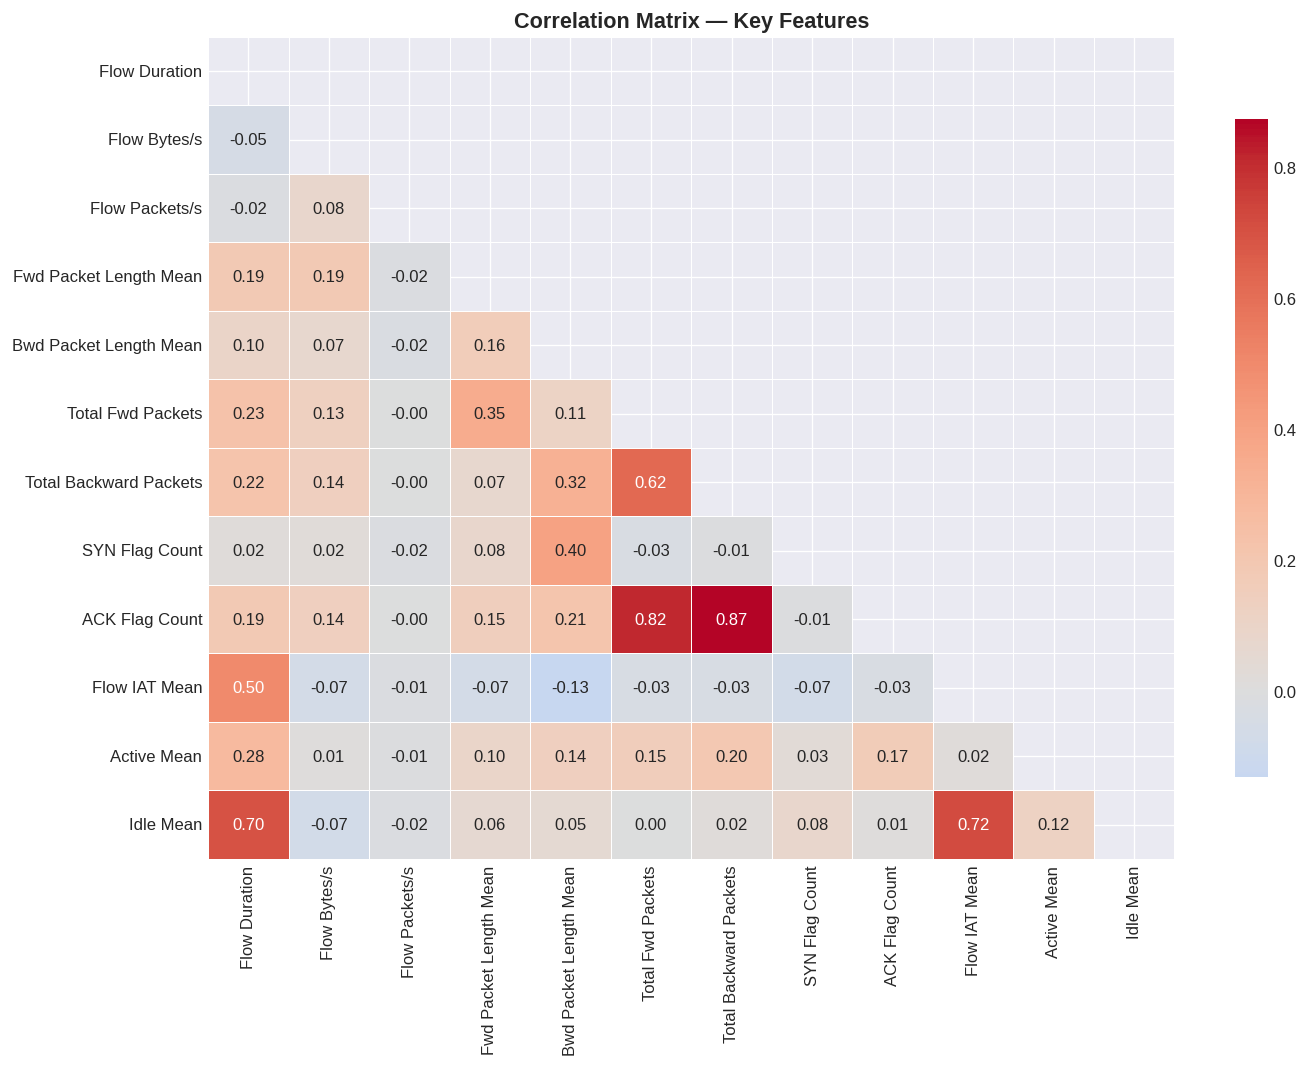

In [52]:
print('='*70)
print('STEP 5A : CORRELATION MATRIX — KEY FEATURES')
print('='*70)

corr_features = [
    'Flow Duration', 'Flow Bytes/s', 'Flow Packets/s',
    'Fwd Packet Length Mean', 'Bwd Packet Length Mean',
    'Total Fwd Packets', 'Total Backward Packets',
    'SYN Flag Count', 'ACK Flag Count', 'Flow IAT Mean',
    'Active Mean', 'Idle Mean'
]
corr_features = [f for f in corr_features if f in df.columns]

corr_subset = df[corr_features].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_subset, dtype=bool))
sns.heatmap(
    corr_subset, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    cbar_kws={'shrink': 0.8}, ax=ax
)
ax.set_title('Correlation Matrix — Key Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Interpretation of the Correlation Heatmap:**
- Strong positive correlations (deep red) are expected between packet-count and byte-count features (e.g., `Total Fwd Packets` and `Fwd Packet Length Mean` × `Total Fwd Packets` ≈ total bytes).
- `Flow Duration` is expected to correlate negatively with `Flow Packets/s` and `Flow Bytes/s` (shorter flows tend to have higher instantaneous rates).
- Correlations between forward and backward metrics (e.g., `Fwd Packet Length Mean` vs. `Bwd Packet Length Mean`) reflect bidirectional communication patterns — the degree of correlation varies significantly between normal and attack traffic.
- The lower-triangular mask eliminates duplicate entries and improves readability.


In [53]:
print('='*70)
print('STEP 5B : HIGHLY CORRELATED PAIRS (|r| > 0.90) — ALL FEATURES')
print('='*70)

numeric_df    = df.select_dtypes(include=np.number)
corr_full     = numeric_df.corr().abs()
threshold     = 0.90

high_corr_pairs = []
for i in range(len(corr_full.columns)):
    for j in range(i+1, len(corr_full.columns)):
        val = corr_full.iloc[i, j]
        if val > threshold:
            high_corr_pairs.append({
                'Feature 1'   : corr_full.columns[i],
                'Feature 2'   : corr_full.columns[j],
                'Correlation' : round(val, 4)
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', ascending=False)
print(f'\n  Pairs with |r| > {threshold} : {len(high_corr_df)}')
print(high_corr_df.to_string(index=False))

# Identify candidate columns to drop
# Strategy: keep Feature 1 of each correlated pair
cols_to_remove_corr = set()
for _, row in high_corr_df.iterrows():
    if row['Feature 1'] not in cols_to_remove_corr:
        cols_to_remove_corr.add(row['Feature 2'])

print(f'\n  Candidate redundant columns for removal: {len(cols_to_remove_corr)}')
for c in sorted(cols_to_remove_corr):
    print(f'    ✗ {c}')


STEP 5B : HIGHLY CORRELATED PAIRS (|r| > 0.90) — ALL FEATURES

  Pairs with |r| > 0.9 : 37
                  Feature 1                   Feature 2  Correlation
     Fwd Packet Length Mean        Avg Fwd Segment Size       1.0000
     Bwd Packet Length Mean        Avg Bwd Segment Size       1.0000
               Flow IAT Max                    Idle Max       0.9992
         Bwd Avg Bytes/Bulk        Bwd Avg Packets/Bulk       0.9989
         Packet Length Mean         Average Packet Size       0.9967
             Flow Packets/s               Fwd Packets/s       0.9942
             Flow Packets/s               Bwd Packets/s       0.9940
Total Length of Fwd Packets            act_data_pkt_fwd       0.9903
              Flow Duration               Fwd IAT Total       0.9849
                  Idle Mean                    Idle Min       0.9805
      Fwd Packet Length Min           Min Packet Length       0.9792
          Packet Length Std      Packet Length Variance       0.9787
     Total B

**Key Findings:**
- The number of highly correlated pairs confirms the high degree of redundancy typical of CICFlowMeter-generated datasets, which compute multiple statistical moments (mean, std, min, max) of the same underlying measurement.
- The greedy "keep Feature 1, drop Feature 2" heuristic used here is conservative; a domain-informed protection mechanism will be applied in Cleaning Step N7 to preserve asymmetric directional features.
- This analysis motivates the feature reduction step (N7) but does **not** directly drive it — the actual removal will apply explicit domain protection.

**Conclusion of EDA — Correlation Analysis:**
The feature space contains significant redundancy from CICFlowMeter's statistical aggregation methodology. Systematic correlation-based pruning, combined with domain knowledge of network traffic asymmetry, will reduce dimensionality while preserving detection-relevant information.


---
## 7. Outlier Analysis (Quantified)

### Objective
Systematically quantify the prevalence of statistical outliers across all numerical features using two complementary methods:

| Method | Criterion | Characteristics |
|---|---|---|
| **IQR (Tukey's fences)** | x < Q1 − 1.5·IQR or x > Q3 + 1.5·IQR | Non-parametric, robust to non-Gaussian distributions |
| **Z-score** | \|z\| > 3 | Parametric, assumes approximate normality |

### Methodological Note
Both methods are applied in parallel to cross-validate the outlier profile. For heavily skewed distributions (as observed in network traffic), the IQR method is more reliable. Z-score counts serve as a secondary reference. The discrepancy between the two methods for a given feature quantifies the degree of non-Gaussianity.


In [54]:
print('='*70)
print('STEP 6 : OUTLIER QUANTIFICATION (IQR + Z-SCORE)')
print('='*70)

outlier_report = []

for col in num_cols:
    data = df[col].dropna()
    if data.std() == 0:
        continue

    # IQR method
    q1, q3 = data.quantile([0.25, 0.75])
    iqr     = q3 - q1
    lo, hi  = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_iqr   = ((data < lo) | (data > hi)).sum()

    # Z-score method
    z       = zscore(data)
    n_z     = (np.abs(z) > 3).sum()

    if n_iqr > 0:
        outlier_report.append({
            'Feature'      : col,
            'IQR Outliers' : n_iqr,
            'IQR %'        : f'{n_iqr/len(data)*100:.2f}%',
            'Z Outliers'   : n_z,
            'Z %'          : f'{n_z/len(data)*100:.2f}%',
        })

outlier_report_df = pd.DataFrame(outlier_report).sort_values('IQR Outliers', ascending=False)
print(f'\n  Features with IQR outliers: {len(outlier_report_df)}')
print()
print(outlier_report_df.to_string(index=False))


STEP 6 : OUTLIER QUANTIFICATION (IQR + Z-SCORE)

  Features with IQR outliers: 71

                    Feature  IQR Outliers  IQR %  Z Outliers   Z %
                  Idle Mean          1227 23.50%         198 3.79%
                   Idle Min          1227 23.50%         224 4.29%
                   Idle Max          1227 23.50%          43 0.82%
                Bwd IAT Min          1221 23.38%         126 2.41%
              Bwd IAT Total          1221 23.38%         169 3.24%
          Subflow Fwd Bytes          1214 23.25%          10 0.19%
           Destination Port          1206 23.09%         104 1.99%
               Flow IAT Std          1194 22.86%         134 2.57%
                Active Mean          1192 22.83%          49 0.94%
                 Active Min          1192 22.83%          41 0.79%
                 Active Max          1192 22.83%          69 1.32%
                Fwd IAT Max          1174 22.48%          48 0.92%
     Init_Win_bytes_forward          1160 22.2

**Interpretation:**
- Features with a high IQR outlier percentage but a much lower Z-score percentage are **heavily skewed** (the IQR fence is tight relative to the tail extent).
- Features with high outlier counts in *both* methods are genuinely extreme-valued and require treatment.
- **Flag count features** (e.g., `SYN Flag Count`) may show high outlier counts because a small number of flows set many flags — these are attack signatures and must be preserved.

**Treatment Strategy Preview:**
The outlier treatment applied in Cleaning Step N8 uses **percentile capping (P01–P99)** rather than row deletion. This approach:
- Preserves all observations (important for imbalanced datasets).
- Reduces the influence of extreme values on scaling without destroying attack-indicative patterns.
- Explicitly excludes flag counts and OHE columns from capping.


---
## 8. Categorical Feature Analysis

### Objective
Analyse features that are stored as integers but carry **categorical semantic meaning**: `Protocol` and `Destination Port`. Treating these as continuous numerical variables would impose a false ordinal structure (e.g., implying that TCP (6) is "between" Unknown (0) and UDP (17), or that port 443 is "greater than" port 80).

### Features Under Analysis
- **`Protocol`**: IANA protocol number (0 = Unknown/Other, 6 = TCP, 17 = UDP). Semantically categorical — each value encodes a distinct communication paradigm.
- **`Destination Port`**: Identifies the target service. While numerically encoded, port numbers are nominal — they encode service type (HTTP=80, HTTPS=443, SSH=22, RDP=3389), not magnitude.

### Encoding Strategy Preview
Both features will receive **one-hot encoding** in the cleaning phase (Steps N2 and N4), converting them into binary indicator columns that correctly represent their categorical nature.


STEP 7 : PROTOCOL ANALYSIS (CATEGORICAL VARIABLE)

  Unique Protocol values: [np.int64(0), np.int64(6), np.int64(17)]
  Mapping applied: {6: 'TCP', 17: 'UDP', 0: 'Other/Unknown'}

    6 (TCP            ) :   2594 (49.7%)
    17 (UDP            ) :   2416 (46.3%)
    0 (Other/Unknown  ) :    212 (4.1%)


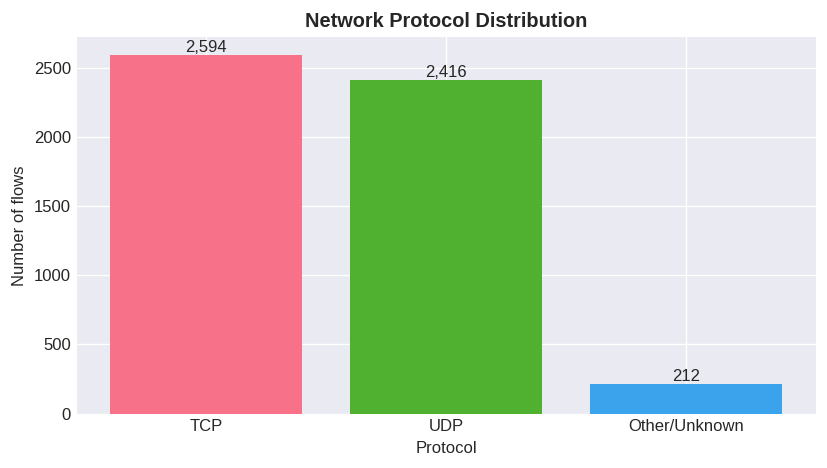

In [55]:
print('='*70)
print('STEP 7 : PROTOCOL ANALYSIS (CATEGORICAL VARIABLE)')
print('='*70)

# Protocol is numeric (6=TCP, 17=UDP, 0=?) but semantically categorical
proto_counts = df['Protocol'].value_counts()
proto_map    = {6: 'TCP', 17: 'UDP', 0: 'Other/Unknown'}

print(f'\n  Unique Protocol values: {sorted(df["Protocol"].unique())}')
print(f'  Mapping applied: {proto_map}')
print()
for val, count in proto_counts.items():
    label = proto_map.get(val, f'Code {val}')
    print(f'    {val} ({label:<15}) : {count:>6} ({count/len(df)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(7, 4))
proto_labels = [proto_map.get(v, str(v)) for v in proto_counts.index]
ax.bar(proto_labels, proto_counts.values, color=sns.color_palette('husl', len(proto_counts)))
ax.set_title('Network Protocol Distribution', fontsize=12, fontweight='bold')
ax.set_xlabel('Protocol')
ax.set_ylabel('Number of flows')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()


**Interpretation:**
- The protocol distribution reveals the dominant communication paradigm in the dataset. TCP-dominated datasets (typical of IoT environments) may require specific attention to TCP flag features.
- The presence of `Protocol = 0` (Unknown) is particularly relevant: in a 6G IoT context, unknown protocols may indicate tunnelling, encapsulation, or evasion techniques — a potential anomaly signal that justifies preserving the `Proto_Other` OHE column.


In [56]:
print('='*70)
print('PORT ANALYSIS — SOURCE & DESTINATION')
print('='*70)

print('\n  Top 10 Destination Ports:')
print(df['Destination Port'].value_counts().head(10).to_string())

well_known_ports = {80:'HTTP', 443:'HTTPS', 22:'SSH', 53:'DNS',
                    21:'FTP', 25:'SMTP', 3389:'RDP', 8080:'HTTP-Alt'}

print('\n  Well-known ports detected:')
for port, name in well_known_ports.items():
    count = (df['Destination Port'] == port).sum()
    if count > 0:
        print(f'    Port {port:>5} ({name:<10}) : {count} flows')


PORT ANALYSIS — SOURCE & DESTINATION

  Top 10 Destination Ports:
Destination Port
53       1516
443      1487
123       310
89        291
0         212
1900      172
80        153
1883      102
8080       55
54102      53

  Well-known ports detected:
    Port    80 (HTTP      ) : 153 flows
    Port   443 (HTTPS     ) : 1487 flows
    Port    22 (SSH       ) : 19 flows
    Port    53 (DNS       ) : 1516 flows
    Port  8080 (HTTP-Alt  ) : 55 flows


**Interpretation:**
- The concentration of flows on well-known ports (80, 443, 22, 53) reflects standard IoT service communication. Anomalous port usage (unusual high ports, scanning across multiple ports) is a primary signal for reconnaissance attacks.
- The `Destination Port` is retained (unlike `Source Port`, which is ephemeral) because it encodes the *targeted service*, which is strongly predictive of attack type.
- One-hot encoding of the top-N most frequent ports (+ an `Port_Other` catch-all) provides a compact representation of service targeting patterns.


---
## 9. TCP Flag Analysis

### Objective
Analyse the distribution and variance of TCP control flags across all flows. TCP flags encode the *control state* of a connection and are among the most diagnostically important features for network intrusion detection:

| Flag | Attack Relevance |
|---|---|
| **SYN** | Elevated count → SYN flood (DDoS) |
| **RST** | High rate → Port scan / connection teardown abuse |
| **FIN** | Abnormal patterns → Evasion, stealth scans |
| **ACK** | Asymmetric ACK → Reflection attacks |
| **PSH** | High rate → Data exfiltration |
| **URG, CWE, ECE** | Rarely set in legitimate traffic → anomaly indicators |

### Critical Insight
Flags with `std = 0` (constant across all flows) are informationless from a statistical perspective and will be removed in Cleaning Step N3. However, **non-constant flag features must never be outlier-capped** (Step N8) or log-transformed (Step N9), as their extreme values represent the very attack patterns the model is designed to detect.


STEP 8 : TCP FLAG BEHAVIOUR

  TCP Flag Statistics:
                   mean       std    min        max  non_zero_%  std_zero
SYN Flag Count   0.4583    0.9121 0.0000     6.0000     21.6009     False
RST Flag Count   0.0421    0.2066 0.0000     2.0000      4.0980     False
FIN Flag Count   0.3777    0.6841 0.0000     3.0000     26.1777     False
ACK Flag Count 169.6261 1934.3360 0.0000 45963.0000     49.1957     False
PSH Flag Count   7.0134   75.8648 0.0000  4221.0000     38.1655     False
URG Flag Count   0.0000    0.0000 0.0000     0.0000      0.0000      True
CWE Flag Count   0.0000    0.0000 0.0000     0.0000      0.0000      True
ECE Flag Count   0.0000    0.0000 0.0000     0.0000      0.0000      True

  → Flags with std=0 (constant) will be dropped during cleaning:
    ✗ URG Flag Count
    ✗ CWE Flag Count
    ✗ ECE Flag Count


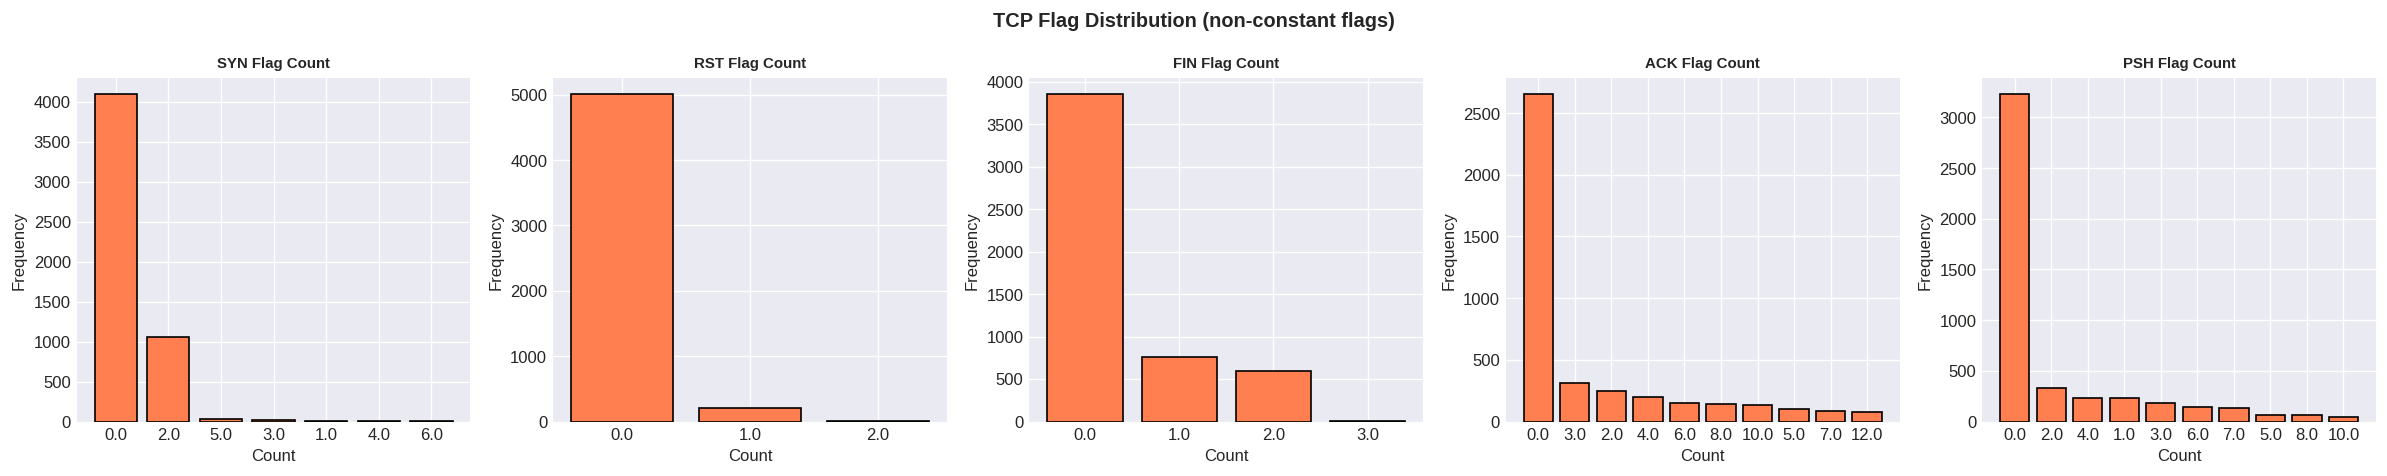

In [57]:
print('='*70)
print('STEP 8 : TCP FLAG BEHAVIOUR')
print('='*70)

flag_features = ['SYN Flag Count','RST Flag Count','FIN Flag Count',
                 'ACK Flag Count','PSH Flag Count','URG Flag Count',
                 'CWE Flag Count','ECE Flag Count']
flag_features = [f for f in flag_features if f in df.columns]

flag_stats = df[flag_features].describe().T[['mean','std','min','max']]
flag_stats['non_zero_%'] = [(df[f] > 0).mean()*100 for f in flag_features]
flag_stats['std_zero']   = [df[f].std() == 0 for f in flag_features]

print('\n  TCP Flag Statistics:')
print(flag_stats.round(4).to_string())
print('\n  → Flags with std=0 (constant) will be dropped during cleaning:')
const_flags = flag_stats[flag_stats['std_zero'] == True].index.tolist()
for f in const_flags:
    print(f'    ✗ {f}')

# Visualisation
non_const_flags = [f for f in flag_features if f not in const_flags]
if non_const_flags:
    fig, axes = plt.subplots(1, len(non_const_flags), figsize=(4*len(non_const_flags), 4))
    if len(non_const_flags) == 1: axes = [axes]
    for ax, flag in zip(axes, non_const_flags):
        vc = df[flag].value_counts().head(10)
        ax.bar(vc.index.astype(str), vc.values, color='coral', edgecolor='black')
        ax.set_title(flag, fontsize=9, fontweight='bold')
        ax.set_xlabel('Count')
        ax.set_ylabel('Frequency')
    plt.suptitle('TCP Flag Distribution (non-constant flags)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


**Key Findings:**
- Constant flags (std = 0) — typically `URG`, `CWE`, `ECE` — will be removed as zero-variance features in Step N3.
- Non-constant flags (e.g., `SYN Flag Count`, `ACK Flag Count`, `RST Flag Count`) exhibit highly sparse distributions: most flows have 0 flag events, with a long right tail. This sparsity is *structurally meaningful* and must be preserved.
- The `non_zero_%` column quantifies flag activity prevalence, informing the expected signal-to-noise ratio in anomaly detection.

**Conclusion — EDA Phase:**
The exploratory analysis reveals a dataset with high dimensionality, pervasive right-skew, significant inter-feature correlation, and domain-critical flag features requiring special treatment. These findings directly motivate the semantics-aware cleaning pipeline implemented in the following section.
